In [1]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph , END
from sentence_transformers import SentenceTransformer
from langchain_core.documents import Document
from dotenv import load_dotenv
from pymongo import MongoClient
from langchain_groq import ChatGroq
import requests
import re
from openai import OpenAI

d:\6th sem\CampusAI\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
MONGO_URI = os.getenv("MONGO_URI")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [4]:
llm = ChatGroq(groq_api_key= os.getenv("GROQ_API_KEY") , model_name="llama-3.1-8b-instant",temperature=0.1,max_tokens=1024)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B8F33BC620>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B8F32A6DB0>, model_name='llama-3.1-8b-instant', temperature=0.1, model_kwargs={}, groq_api_key=SecretStr('**********'), max_tokens=1024)

State Definition

In [5]:
class AgentState(TypedDict):
    question : str
    documents : List[str]
    ans : str
    query_type : str
    needs_retrieval : bool

### Decide Whether to retrieve or not

In [6]:
def decide_retrieval(state: AgentState) -> AgentState:
    question = state["question"]
    prompt = f"""
You are a decision controller in a Retrieval-Augmented Generation (RAG) system for a university assistant called CampusAI.

The system has access to a MongoDB knowledge base containing university documents such as:
- academic rules
- syllabus
- course information
- attendance policies
- exam regulations
- placement data
- faculty information
- campus facilities
- All Notices
Your task is to decide whether the system should RETRIEVE information from the knowledge base or directly GENERATE an answer.

Decision Rules:

Choose RETRIEVE if the question:
- asks about university policies, rules, syllabus, courses, exams, notices or placements
- refers to campus-specific information
- requires factual information likely stored in university documents
- requires accurate or official information

Choose GENERATE if the question:
- is general knowledge
- is conversational
- is opinion-based
- can be answered without university documents

If you are unsure, choose RETRIEVE.

User Question:
"{question}"

Respond with ONLY one word:

RETRIEVE
or
GENERATE
"""
    response = llm.invoke(prompt)
    decision = response.content.strip().upper().replace(".","")
    if decision not in {"RETRIEVE","GENERATE"}:
        decision = "RETRIEVE"
    needs_retrieval = decision == "RETRIEVE"
    return {**state, "needs_retrieval": needs_retrieval}

### Decide the route from (notice , pyq , academic)

In [7]:
def route_query_type_node(state: AgentState) -> AgentState:
    question = state["question"]

    prompt = f"""
You are an intent router in a university AI assistant called CampusAI.

Your task is to classify the user question into ONE of the following categories.

Categories:

1. pyqQuery
Use this if the question is about:
- previous year question papers
- exam papers
- past exam questions
- PYQs

2. noticeQuery
Use this if the question is about:
- university notices
- announcements
- updates
- deadlines

3. academicQuery
Use this if the question is about:
- syllabus
- attendance rules
- course structure
- exam regulations
- placements
- faculty
- departments
- academic policies
- any other university academic information

If unsure, choose **academicQuery**.

User Question:
"{question}"

Respond with ONLY ONE of the following words:

pyqQuery
noticeQuery
academicQuery
"""

    response = llm.invoke(prompt)
    decision = response.content.strip().replace(".", "")

    if decision not in {"pyqQuery", "noticeQuery", "academicQuery"}:
        decision = "academicQuery"

    return {**state, "query_type": decision}

In [8]:
client = MongoClient(MONGO_URI)
db = client["campus_ai"]


In [9]:
# Notice  retriever
def retrieve_notice_context(state: AgentState) -> AgentState:
    """
    Retrieve relevant notices from MongoDB and return formatted context
    """
    vector_col = db["notice_vector"]
    MODEL_NAME = "models/gemini-embedding-001"
    BASE_URL = "https://generativelanguage.googleapis.com/v1beta"
    INDEX_NAME = "default"
    query = state["question"]
    endpoint = f"{BASE_URL}/{MODEL_NAME}:embedContent?key={GEMINI_API_KEY}"
    response = requests.post(
        endpoint,
        json={
            "content": {
                "parts": [{"text": query}]
            }
        }
    )
    if response.status_code != 200:
        raise Exception(f"Gemini API Error: {response.text}")

    query_embedding = response.json()["embedding"]["values"]

    pipeline = [
        {
            "$vectorSearch": {
                "index": INDEX_NAME,
                "path": "embedding",
                "queryVector": query_embedding,
                "numCandidates": 100,
                "limit": 1
            }
        },
        {
            "$project": {
                "_id": 0,
                "post_id": 1,
                "content": 1,
                "metadata": 1,
                "score": {"$meta": "vectorSearchScore"}
            }
        }
    ]

    results = list(vector_col.aggregate(pipeline))
    context_blocks = []

    for r in results:
        block = f"""
Title: {r['metadata'].get('title')}
Date: {r['metadata'].get('date')}
Notice URL: {r['metadata'].get('notice_url')}
PDF URL: {r['metadata'].get('pdf_url')}
Content:
{r['content']}
"""
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return {**state, "documents": context}

In [10]:
# Load model once globally
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


def embed_query(query: str):
    vec = model.encode(query, normalize_embeddings=True)
    return vec.tolist()


def retrieve_academic_context(state: AgentState) -> AgentState:
    """
    Retrieve relevant academic documents from MongoDB using vector search
    and return formatted context.
    """

    vector_col = db["academic_vector"]
    INDEX_NAME = "academic_index"

    query = state["question"]

    # Generate embedding
    query_vector = embed_query(query)

    pipeline = [
        {
            "$vectorSearch": {
                "index": INDEX_NAME,
                "path": "values",   
                "queryVector": query_vector,
                "numCandidates": 100,
                "limit": 5
            }
        },
        {
            "$project": {
                "_id": 0,
                "id": 1,
                "metadata": 1,
                "score": {"$meta": "vectorSearchScore"}
            }
        }
    ]

    results = list(vector_col.aggregate(pipeline))
    context = [r["metadata"]["text"] for r in results]
    return {**state, "documents": context}

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3433.45it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
# PYQ retriever
collection = db["pyq_papers"]
def parse_user_query(text):

    text = text.lower()

    query = {
        "course": "btech",
        "branch": "cse",
        "is_active": True
    }

    # ----------------------------
    # Extract semester
    # ----------------------------
    sem_match = re.search(r'sem\s*(\d+)', text)
    if sem_match:
        query["semester"] = int(sem_match.group(1))
    else:
        num_match = re.search(r'\b([3-8])\b', text)
        if num_match:
            query["semester"] = int(num_match.group(1))

    # ----------------------------
    # Extract exam type
    # ----------------------------
    if "end" in text:
        query["exam_type"] = "end"
    elif "mid" in text:
        query["exam_type"] = "mid"

    # ----------------------------
    # Extract subject code
    # ----------------------------
    code_match = re.search(r'[a-z]{3,4}\d{3}', text)
    if code_match:
        query["subject_code"] = code_match.group(0).upper()
    else:
        # Remove common words
        cleaned = re.sub(r'\b(btech|cse|sem|semester|end|mid|paper|papers|\d)\b', '', text)
        cleaned = cleaned.strip()

        if cleaned:
            query["subject_name"] = {
                "$regex": cleaned,
                "$options": "i"
            }

    return query


def search_papers(user_query):

    mongo_query = parse_user_query(user_query)

    print("Mongo Query:", mongo_query)

    results = collection.find(mongo_query).sort("year", -1)

    papers = []

    for doc in results:
        papers.append({
            "subject_name": doc["subject_name"],
            "subject_code": doc["subject_code"],
            "semester": doc["semester"],
            "exam_type": doc["exam_type"],
            "year": doc["year"],
            "paper_set": doc.get("paper_set"),
            "pdf_url": doc["pdf_url"]
        })

    return papers
def retrieve_pyq_context(state: AgentState) -> AgentState:
    """
    Retrieve relevant previous year question papers from MongoDB and return formatted context
    """
    query = state["question"]
    papers = search_papers(query)

    context_blocks = []
    for p in papers:
        block = f"""Subject: {p['subject_name']} ({p['subject_code']})
Semester: {p['semester']}
Exam Type: {p['exam_type']}
Year: {p['year']}
Paper Set: {p.get('paper_set', 'N/A')}
PDF: {p['pdf_url']}
"""
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)

    return {**state, "documents": context}

In [12]:
## Generator Function
def generate_ans(state: AgentState) -> AgentState:
    """
    Generate an answer using the retrieved documents or direct response
    """
    print("STATE KEYS:", state.keys())
    question = state["question"]
    context = state["documents"]

    if context:
        prompt = f"""Based on the following context, answer the question:

Context:
{context}

Question: {question}
NOTE: For Notice contect add notice_url ,pdf_url and date(formated-DD/MM/YYYY) to answer if available in context. 
Answer:"""
    else:
        prompt = f"Answer the following question: {question}"
    llm = ChatGroq(groq_api_key= os.getenv("GROQ_API_KEY2") , model_name="llama-3.1-8b-instant",temperature=0.1,max_tokens=1024)
    response = llm.invoke(prompt)
    answer = response.content
    return {**state, "ans": answer}

In [13]:
def should_retrieve(state: AgentState)-> str:
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

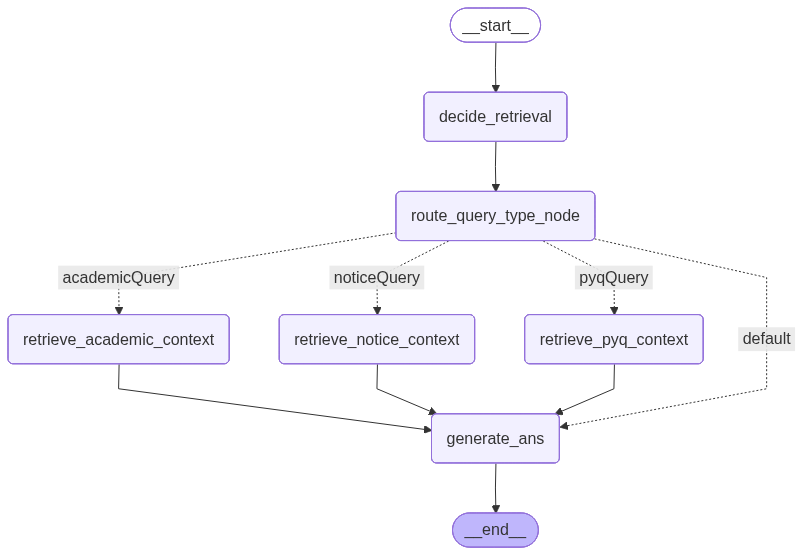

In [14]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

# Nodes
workflow.add_node("decide_retrieval", decide_retrieval)
workflow.add_node("route_query_type_node", route_query_type_node)
workflow.add_node("retrieve_notice_context", retrieve_notice_context)
workflow.add_node("retrieve_academic_context", retrieve_academic_context)
workflow.add_node("retrieve_pyq_context", retrieve_pyq_context)
workflow.add_node("generate_ans", generate_ans)

# Start edge
workflow.add_edge(START, "decide_retrieval")

# Normal edge
workflow.add_edge("decide_retrieval", "route_query_type_node")

# Conditional routing
workflow.add_conditional_edges(
    "route_query_type_node",
    lambda state: state["query_type"],
    {
        "noticeQuery": "retrieve_notice_context",
        "academicQuery": "retrieve_academic_context",
        "pyqQuery": "retrieve_pyq_context",
        "default": "generate_ans"
    }
)

# Retrieval → answer
workflow.add_edge("retrieve_notice_context", "generate_ans")
workflow.add_edge("retrieve_academic_context", "generate_ans")
workflow.add_edge("retrieve_pyq_context", "generate_ans")

# End
workflow.add_edge("generate_ans", END)

app = workflow.compile()
app

In [15]:
def ask_question(question: str):
    initial_state = {
        "question": question,
        "documents": [],
        "ans": "",
        "needs_retrieval": False
    }
    result = app.invoke(initial_state)
    return result

In [18]:
result = ask_question("B.Tech cse fee information")
# print(result['needs_retrieval'])
# print(result['documents'])
print(result['query_type'])
print(result['ans'])


STATE KEYS: dict_keys(['question', 'documents', 'ans', 'query_type', 'needs_retrieval'])
academicQuery
Based on the provided context, the answer to the question "B.Tech cse fee information" is:

 Fee information is available under the 'Academic Fee Structure' option. 

However, the exact fee structure is not mentioned in the given context. 

To get the latest and accurate fee information, you can visit the official website of Graphic Era Hill University at https://gehu.ac.in/fee/ddn/btech-cse.


In [19]:
result = ask_question("btech cse 6thsem TCS601 mid pyq paper")
# print(result['needs_retrieval'])
# print(result['documents'])
print(result['query_type'])
print(result['ans'])

Mongo Query: {'course': 'btech', 'branch': 'cse', 'is_active': True, 'exam_type': 'mid', 'subject_code': 'TCS601'}
STATE KEYS: dict_keys(['question', 'documents', 'ans', 'query_type', 'needs_retrieval'])
pyqQuery
Based on the provided context, I can provide the mid-semester question paper for Compiler Design (TCS601) for the 6th semester of B.Tech CSE for the years 2022, 2023, and 2024.

For 2022:
- Exam Type: mid
- Year: 2022
- PDF: https://raw.githubusercontent.com/gehuhaldwani/pyqs/main/btech/CSE/sem 6/compiler design/mid/tcs601_midsem_2022_may.pdf

For 2023:
- Exam Type: mid
- Year: 2023
- PDF: https://raw.githubusercontent.com/gehuhaldwani/pyqs/main/btech/CSE/sem 6/compiler design/mid/tcs601_midsem_2023_apr.pdf

For 2024:
- Exam Type: mid
- Year: 2024
- PDF: https://raw.githubusercontent.com/gehuhaldwani/pyqs/main/btech/CSE/sem 6/compiler design/mid/tcs601_midsem_2024_mar.pdf


In [ ]:
result = ask_question("notice regarding PBL 2nd phase schedule")
# print(result['needs_retrieval'])
# print(result['documents'])
print(result['query_type'])
print(result['ans'])

STATE KEYS: dict_keys(['question', 'documents', 'ans', 'query_type', 'needs_retrieval'])
noticeQuery
Dear students, PBL 2nd phase is scheduled from 23rd to 31st March, 2026. Kindly be alert on the PBL website to checkout date and timings of the evaluation. Note: Do not miss any of your regular classes for evaluation!

- Notice URL: http://btechcsegehu.in/2026/03/20/notice-pbl-2nd-phase-evaluation-2/
- PDF URL: None
- Date: 20/03/2026


In [32]:
result = ask_question("give list of top placament records")
# print(result['needs_retrieval'])
# print(result['documents'])
print(result['query_type'])
print(result['ans'])

STATE KEYS: dict_keys(['question', 'documents', 'ans', 'query_type', 'needs_retrieval'])
academicQuery
Here's the list of top placement records:

1. **Darshit Joshi** - Computer Science & Engineering - Amazon - 47.88 Lacs
2. **Ikshit Dhyani** - Computer Science & Engineering - Amazon - 47.88 Lacs
3. **Divyansh Bhadra** - Computer Science & Engineering - Amazon - 47.88 Lacs
4. **Vaibhav Gaur** - Computer Science & Engineering - Amazon - 47.88 Lacs
5. **Chandni Mishra** - CS (GEN) - Amazon - 47.88 Lacs
6. **Shreya Sharma** - CS (ML & AI) - Amazon - 47.88 Lacs
7. **Pawandeep Kaur** - CS (GEN) - Intuit - 44.92 Lacs
8. **Epsita Mukherjee** - CS (GEN) - Paypal - 34.40 Lacs
9. **Shreya Sharma** - CS (ML & AI) - Paypal - 34.40 Lacs
10. **Prakhar Dhyani** - CS (GEN) - Paypal - 34.40 Lacs

Note: There are multiple students with the same name and placement record. I have listed them separately for clarity.
